# Imports

In [2]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Varying model

## load data

In [20]:
save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'
base_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/logs'
baselines = pd.read_csv(f'{base_root}/baselines_chosen.csv')
finetunes_best_all = pd.read_csv(f'{save_root}/finetune_best.csv')

model_list = ['TQNet', 'PDF', 'Fredformer', 'iTransformer']

base = baselines.copy()
base = base[
    ((base.data_id == 'ETTh1') & (base.model.isin(model_list))) |
    ((base.data_id == 'ETTh2') & (base.model.isin(model_list))) |
    ((base.data_id == 'ETTm1') & (base.model.isin(model_list))) |
    ((base.data_id == 'ETTm2') & (base.model.isin(model_list))) |
    ((base.data_id == 'ECL') & (base.model.isin(model_list))) |
    ((base.data_id == 'Weather') & (base.model.isin(model_list)))
]

finetuned = finetunes_best_all.copy()
finetuned = finetuned[
    ((finetuned.data_id == 'ETTh1') & (finetuned.model.isin(model_list))) |
    ((finetuned.data_id == 'ETTh2') & (finetuned.model.isin(model_list))) |
    ((finetuned.data_id == 'ETTm1') & (finetuned.model.isin(model_list))) |
    ((finetuned.data_id == 'ETTm2') & (finetuned.model.isin(model_list))) |
    ((finetuned.data_id == 'ECL') & (finetuned.model.isin(model_list))) |
    ((finetuned.data_id == 'Weather') & (finetuned.model.isin(model_list)))
]

columns = ['model', 'pred_len', 'data_id', 'mse', 'mae']
base = base[columns]
base['label'] = 'w/o QDF'
finetuned = finetuned[columns]
finetuned['label'] = 'with QDF'

df = pd.concat([base, finetuned], axis=0)
df['pred_len'] = df['pred_len'].astype(int)

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df['data_id'] = pd.Categorical(df['data_id'], categories=dst_order, ordered=True)

df['model'] = df['model'].replace({'TQNet': 'TQNet', 'PDF': 'PDF', 'Fredformer': 'Fred.', 'iTransformer': 'iTrans.'})
model_order = ['TQNet', 'PDF', 'Fred.', 'iTrans.']
df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

label_order = ['with QDF', 'w/o QDF']
df['label'] = pd.Categorical(df['label'], categories=label_order, ordered=True)

df.sort_values(by=['data_id', 'model', 'label', 'pred_len'], inplace=True)
df.head()

,model,pred_len,data_id,mse,mae,label
8,TQNet,96,ETTh1,0.365111,0.388897,with QDF
9,TQNet,192,ETTh1,0.427475,0.421499,with QDF
10,TQNet,336,ETTh1,0.465918,0.448515,with QDF
11,TQNet,720,ETTh1,0.466485,0.466534,with QDF
400,TQNet,96,ETTh1,0.372007,0.391440,w/o QDF


## plot

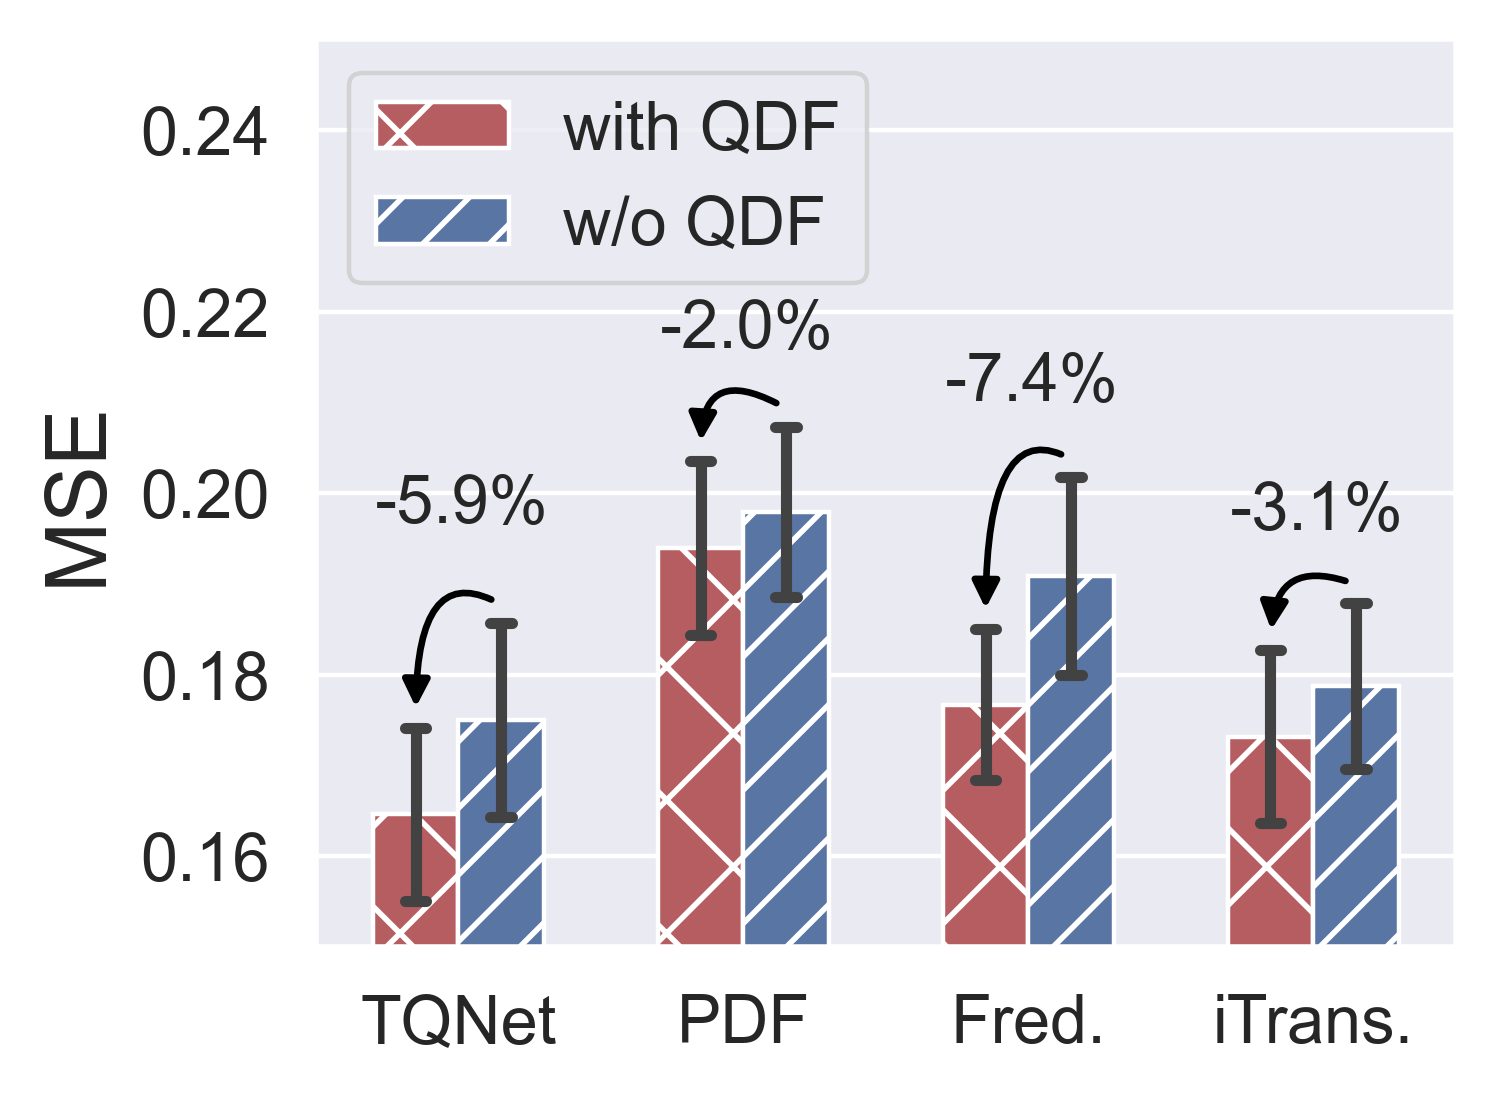

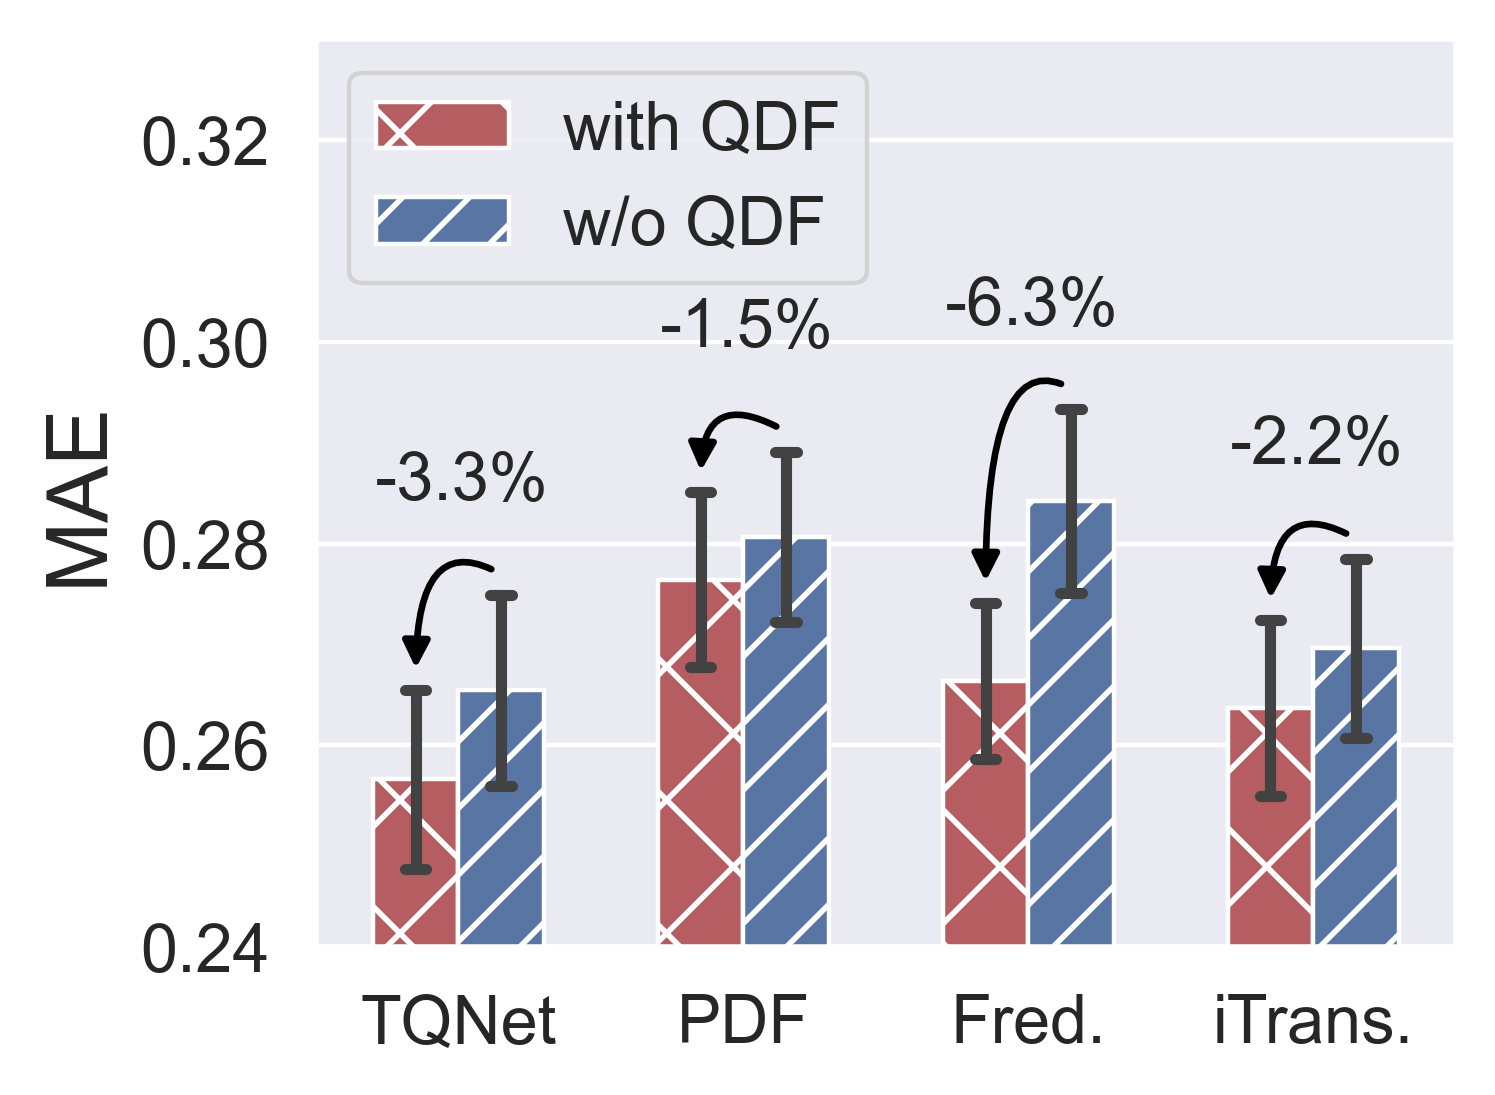

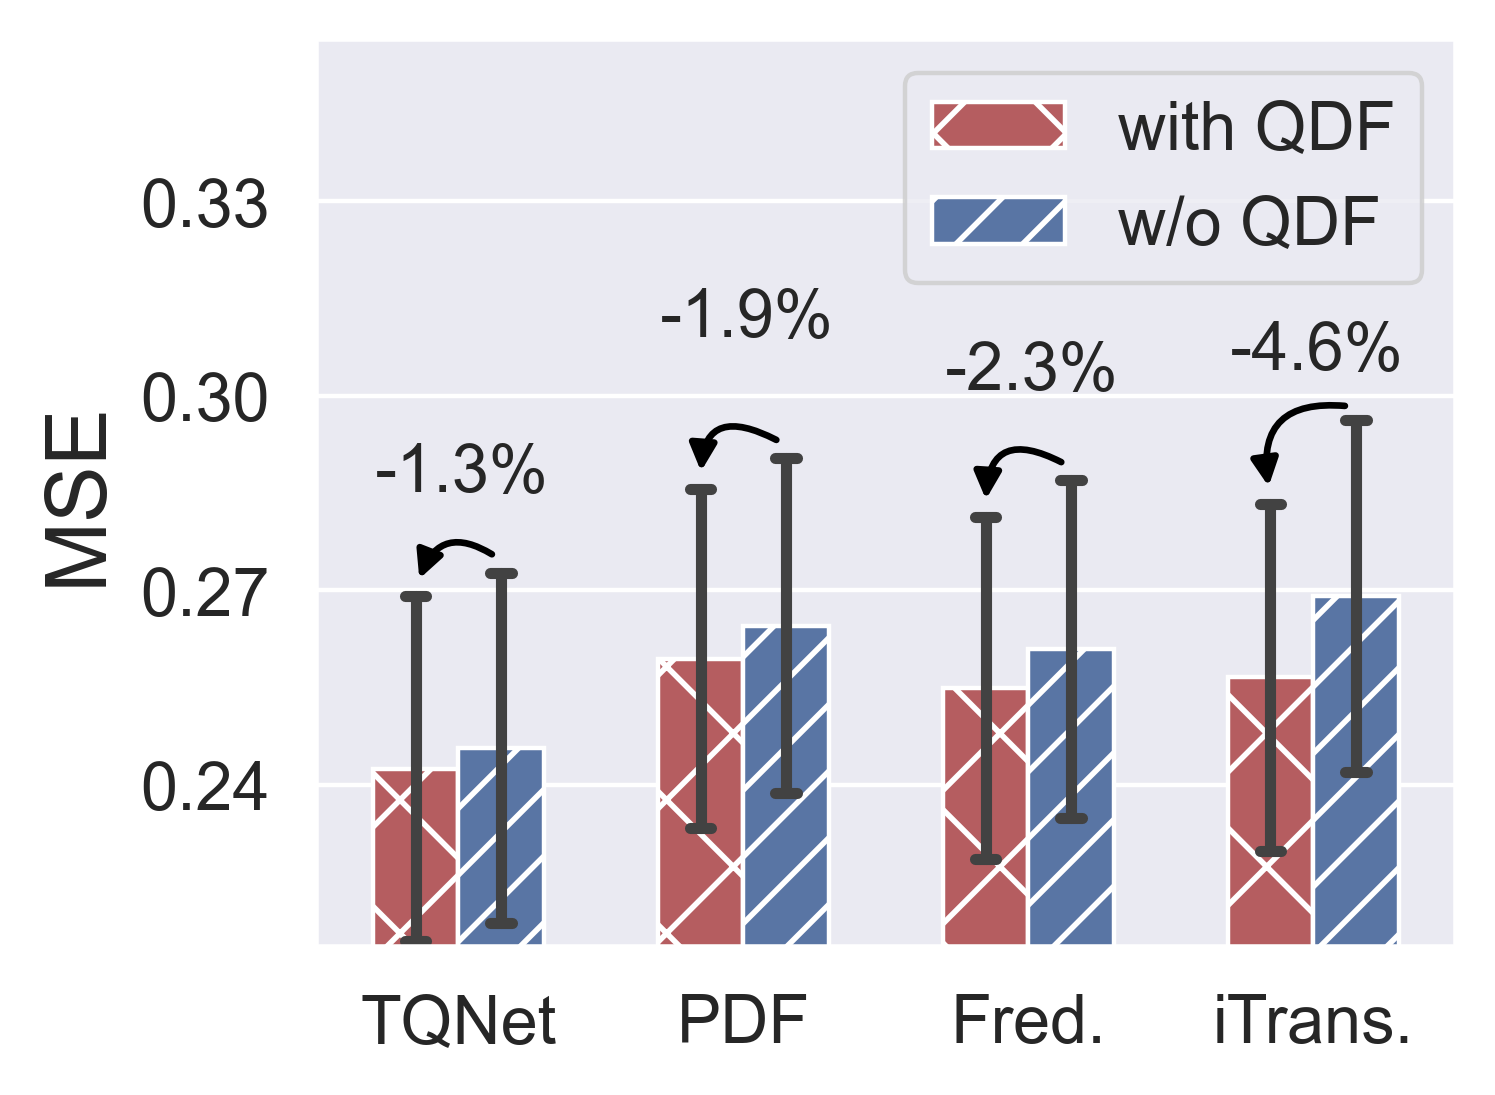

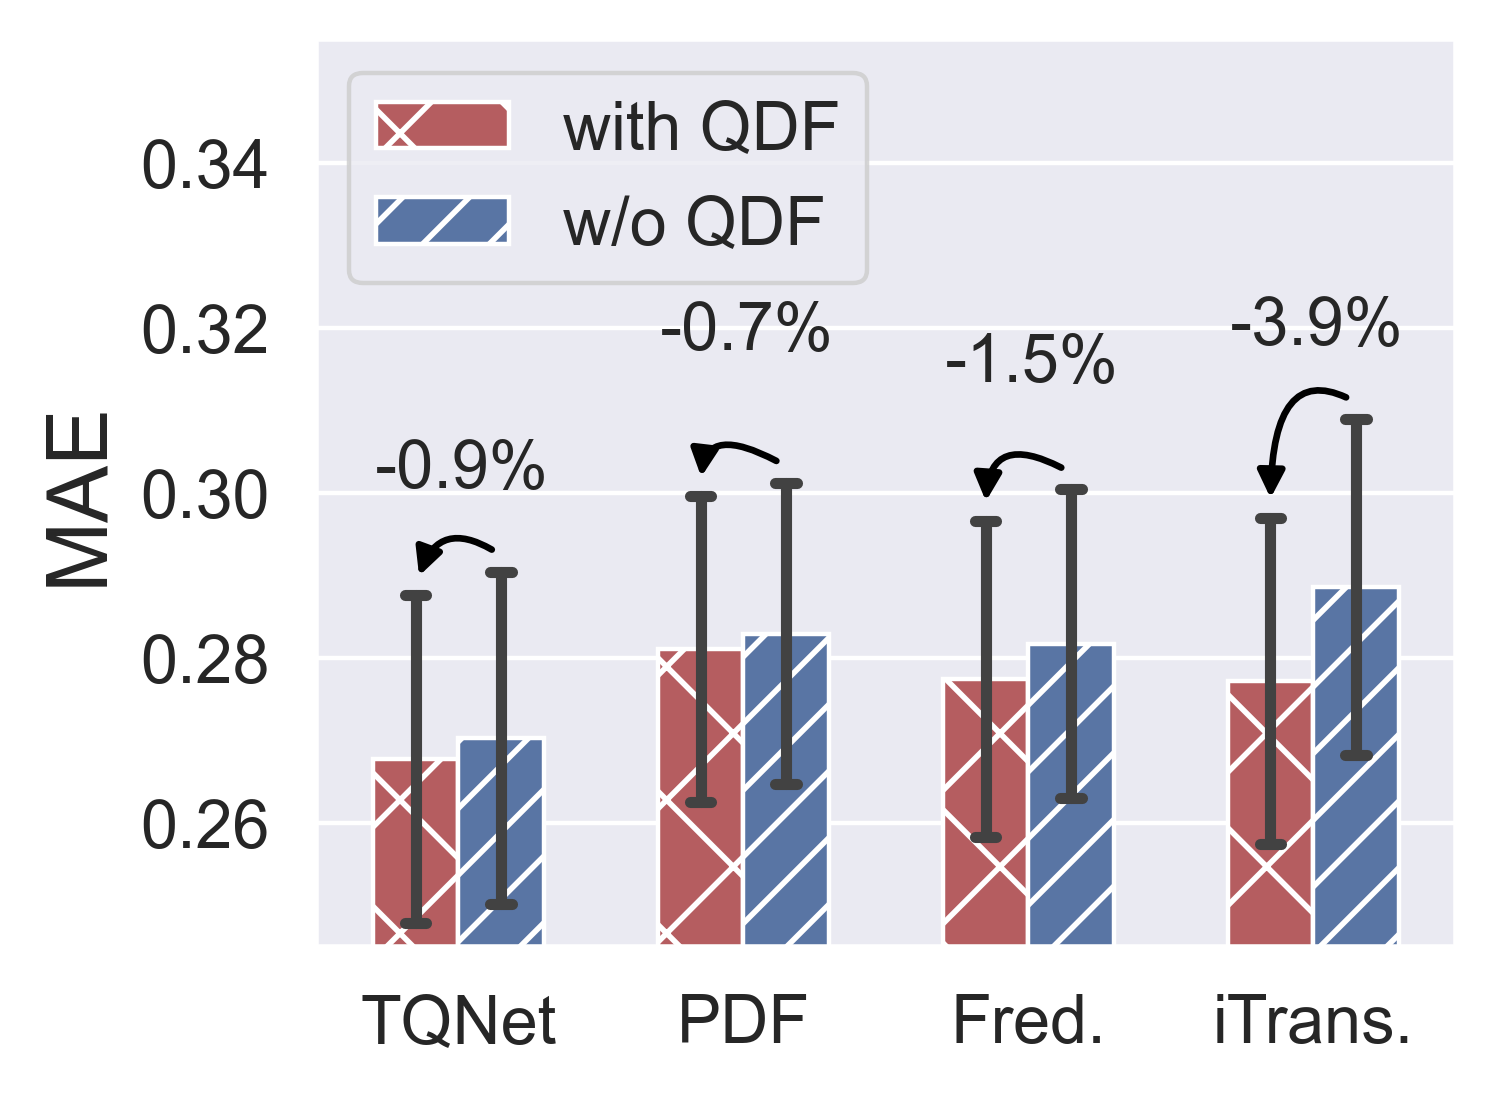

In [21]:
def plot(df, save_dir, dataset, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None, loc1=None, loc2=None):
    labelsize = 12
    width = 0.6
    base = 1
    hatchs = ['x', '//']
    ci = 50
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mse', hue='label', data=df, palette=palette[:2], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*4, (j+1)*4)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,10), hatchs)]

    patches = bar.patches
    ls = bar.lines
    n_models = 4
    yoffset = 0.001
    for i in range(n_models):
        p = patches[i]
        q = patches[i+n_models]
        l1 = ls[i]
        xy1 = l1.get_xydata()
        y1 = xy1[4, 1] + yoffset
        l2 = ls[i+n_models]
        xy2 = l2.get_xydata()
        y2 = xy2[4, 1] + yoffset * 2
        
        if (i in [1, 2] and dataset == "Weather") or \
            (i in [0, 1, 2] and dataset == "ECL"):
            plt.annotate(
                "", xy=(p.get_x()+p.get_width()/2, y1), xycoords='data', 
                xytext=(q.get_x()+q.get_width()/2, y2), textcoords='data', 
                arrowprops=dict(arrowstyle='-|>', connectionstyle='angle3,angleA=-30,angleB=-90', color='black', lw=1.2, mutation_scale=10)
            )
        else:
            plt.annotate(
                "", xy=(p.get_x()+p.get_width()/2, y1), xycoords='data', 
                xytext=(q.get_x()+q.get_width()/2, y2), textcoords='data', 
                arrowprops=dict(arrowstyle='-|>', connectionstyle='arc3,rad=.7', color='black', lw=1.2, mutation_scale=10)
            )
        pmean = p.get_y() + p.get_height()
        qmean = q.get_y() + q.get_height()
        gain = (pmean - qmean) / qmean * 100
        annote = f"{'+' if gain > 0 else '-'}{abs(gain):.1f}%"
        
        if i in [1, 2] and dataset == "Weather":
            if i == 1:
                yoff = 23
            else:
                yoff = 18
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, yoff), textcoords='offset points', fontsize=labelsize
            )
        elif i in [0, 1, 2] and dataset == "ECL":
            if i == 0:
                yoff = 25
            elif i == 1:
                yoff = 15
            elif i == 2:
                yoff = 25
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, yoff), textcoords='offset points', fontsize=labelsize
            )
        else:
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, 15), textcoords='offset points', fontsize=labelsize
            )


    legend_location = 'lower right' if loc1 is None else loc1
    ax = plt.gca()
    plt.legend(fontsize=labelsize, ncols=1, loc=legend_location)
    plt.xlabel('')
    plt.ylabel('MSE')
    # plt.yscale('log', base=2)
    plt.tick_params(labelsize=labelsize)
    if ylim1:
        plt.ylim(ylim1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MSE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


    f = plt.figure(dpi=400, figsize=(4, 3))
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mae', hue='label', data=df, palette=palette[:2], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*4, (j+1)*4)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,10), hatchs)]

    patches = bar.patches
    ls = bar.lines
    n_models = 4
    yoffset = 0.001
    for i in range(n_models):
        p = patches[i]
        q = patches[i+n_models]
        l1 = ls[i]
        xy1 = l1.get_xydata()
        y1 = xy1[4, 1] + yoffset
        l2 = ls[i+n_models]
        xy2 = l2.get_xydata()
        y2 = xy2[4, 1] + yoffset * 2
        
        if (i in [1, 2, 3] and dataset == "Weather") or \
            (i in [0, 1, 2, 3] and dataset == "ECL"):
            plt.annotate(
                "", xy=(p.get_x()+p.get_width()/2, y1), xycoords='data', 
                xytext=(q.get_x()+q.get_width()/2, y2), textcoords='data', 
                arrowprops=dict(arrowstyle='-|>', connectionstyle='angle3,angleA=-30,angleB=-90', color='black', lw=1.2, mutation_scale=10)
            )
        else:
            plt.annotate(
                "", xy=(p.get_x()+p.get_width()/2, y1), xycoords='data', 
                xytext=(q.get_x()+q.get_width()/2, y2), textcoords='data', 
                arrowprops=dict(arrowstyle='-|>', connectionstyle='arc3,rad=.7', color='black', lw=1.2, mutation_scale=10)
            )
        pmean = p.get_y() + p.get_height()
        qmean = q.get_y() + q.get_height()
        gain = (pmean - qmean) / qmean * 100
        annote = f"{'+' if gain > 0 else '-'}{abs(gain):.1f}%"
        
        if i in [1, 2, 3] and dataset == "Weather":
            if i == 1:
                yoff = 23
            elif i == 2:
                yoff = 20
            else:
                yoff = 20
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, yoff), textcoords='offset points', fontsize=labelsize
            )
        elif i in [0, 1, 2, 3] and dataset == "ECL":
            if i == 0:
                yoff = 23
            elif i == 1:
                yoff = 20
            elif i == 2:
                yoff = 30
            else:
                yoff = 20
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, yoff), textcoords='offset points', fontsize=labelsize
            )
        else:
            plt.annotate(
                annote, xy=(p.get_x()+p.get_width(), (y1+y2)/2), 
                xytext=(-15, 15), textcoords='offset points', fontsize=labelsize
            )

    legend_location = 'lower right' if loc2 is None else loc2

    ax = plt.gca()
    # ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    plt.legend(fontsize=labelsize, ncols=1, loc=legend_location)
    plt.ylabel('MAE')
    plt.xlabel('')
    plt.tick_params(labelsize=labelsize)
    if ylim2:
        plt.ylim(ylim2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MAE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


dfp = df.copy()

figure_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
save_dir = f'{figure_root}/backbones'
os.makedirs(save_dir, exist_ok=True)

data_id = 'ECL'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=None, ypad2=None, ylim1=[0.15, 0.25], ylim2=[0.24, 0.33], loc1='upper left', loc2='upper left')

data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=0.03, ypad2=None, ylim1=[0.215, 0.355], ylim2=[0.245, 0.355], loc1='upper right', loc2='upper left')

## plot simple

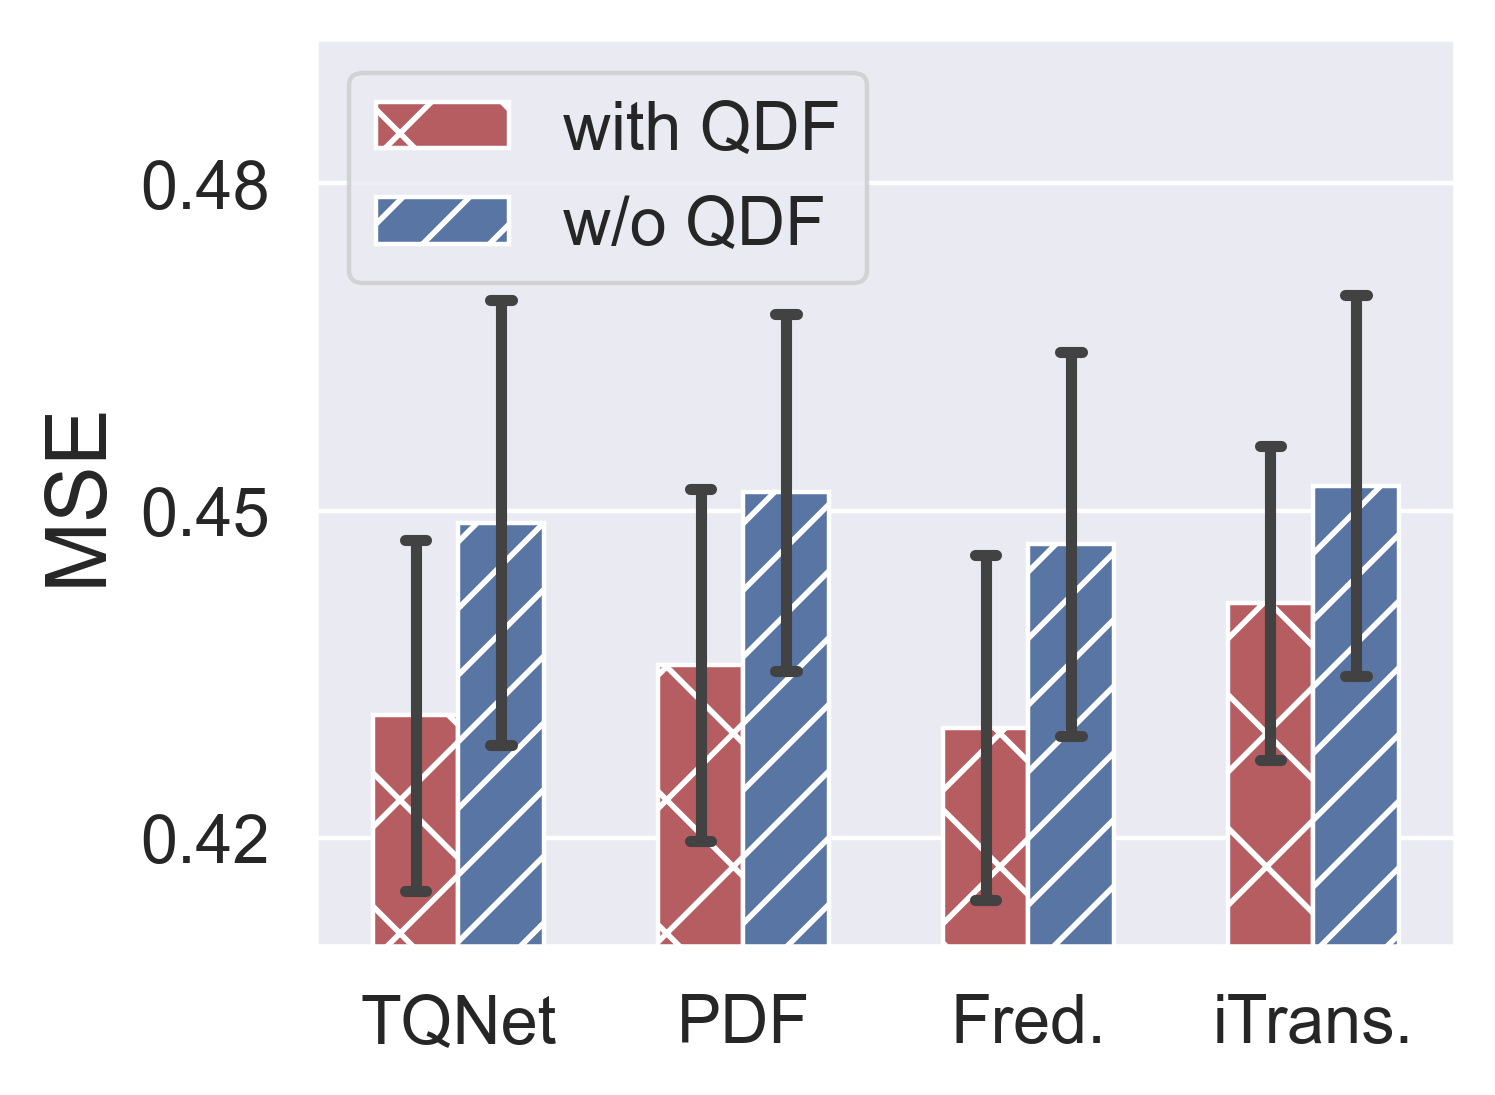

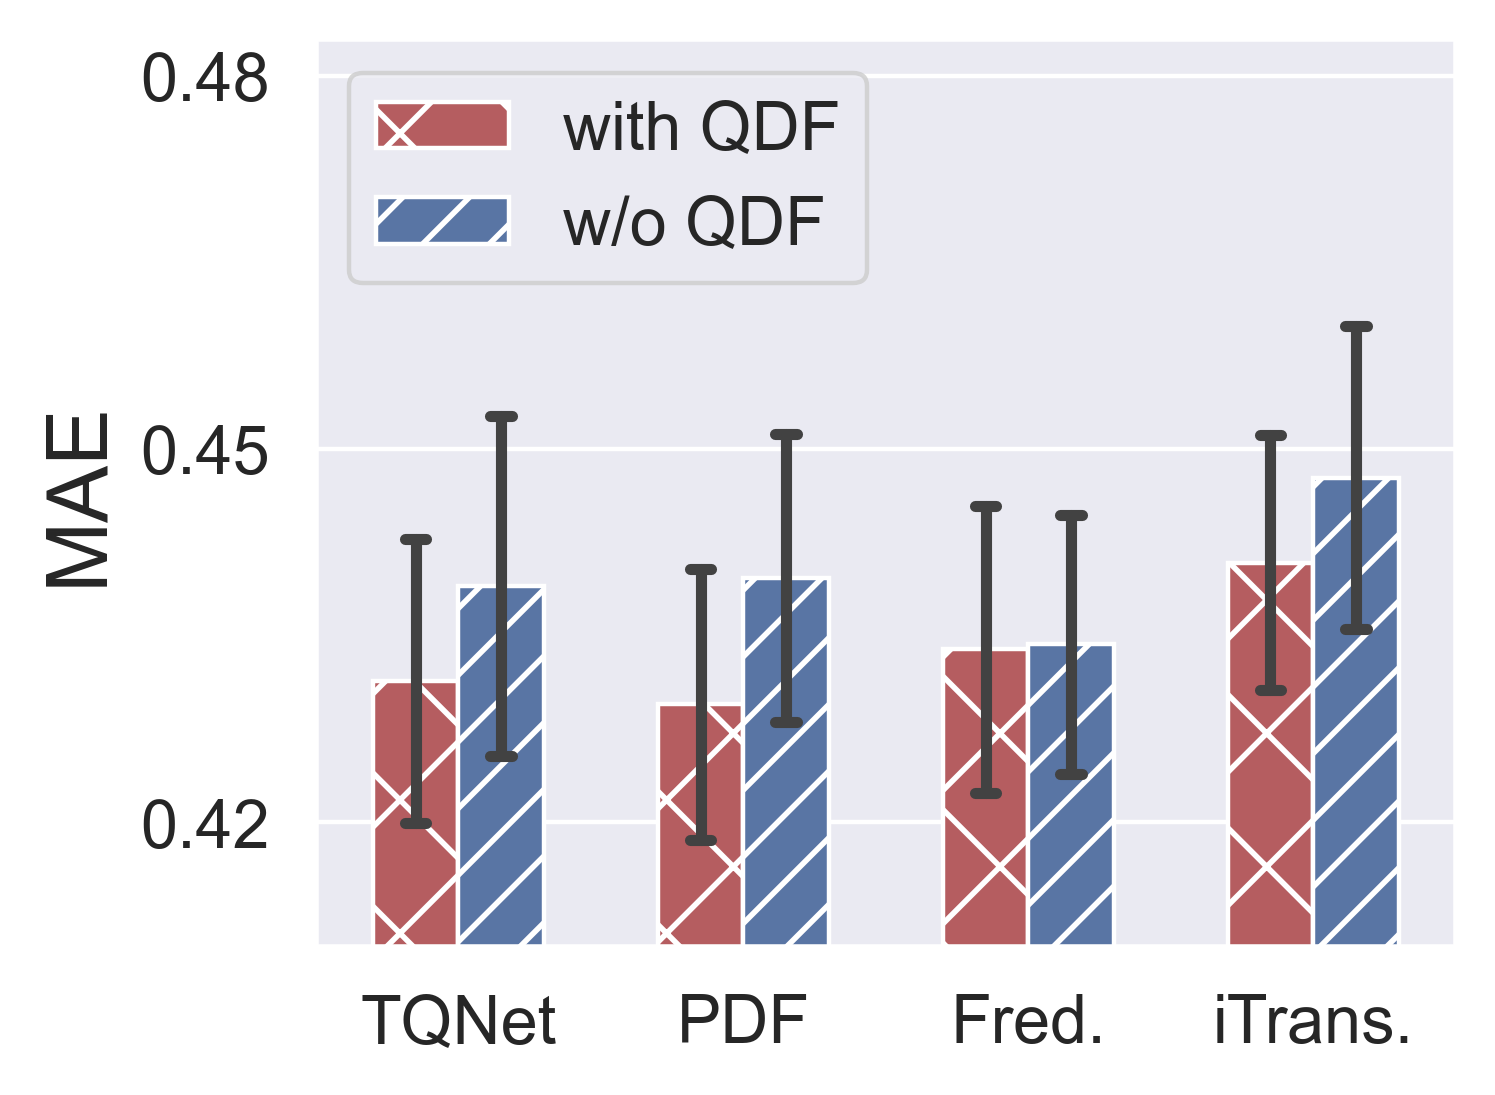

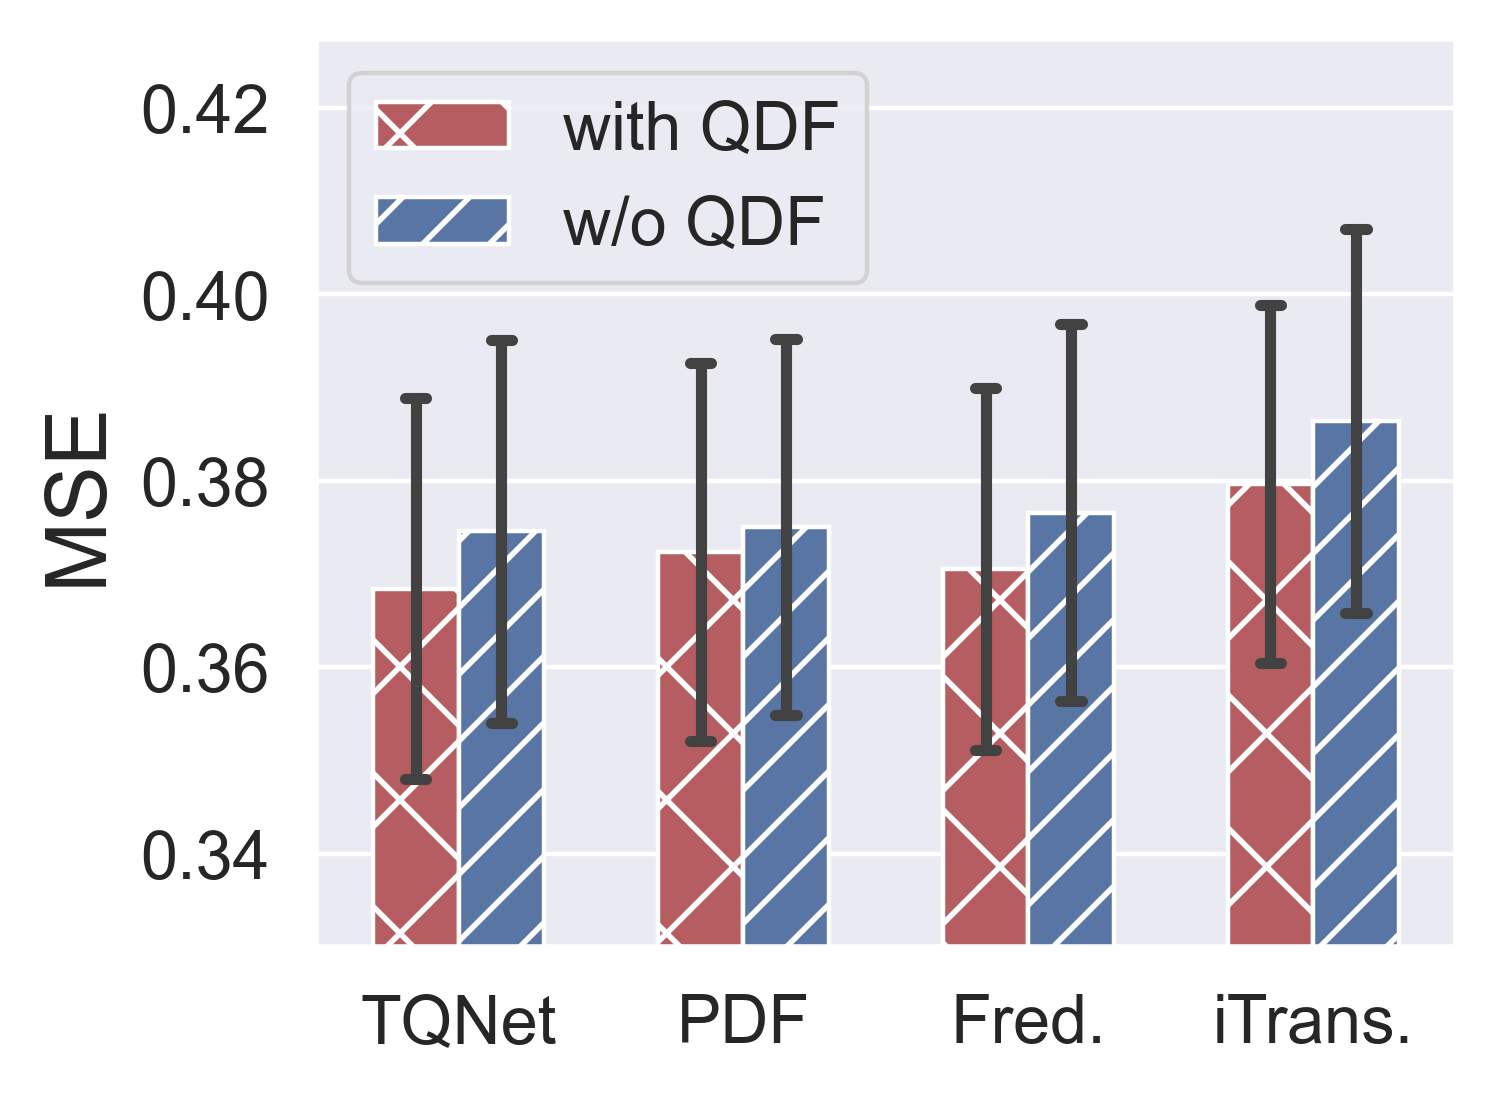

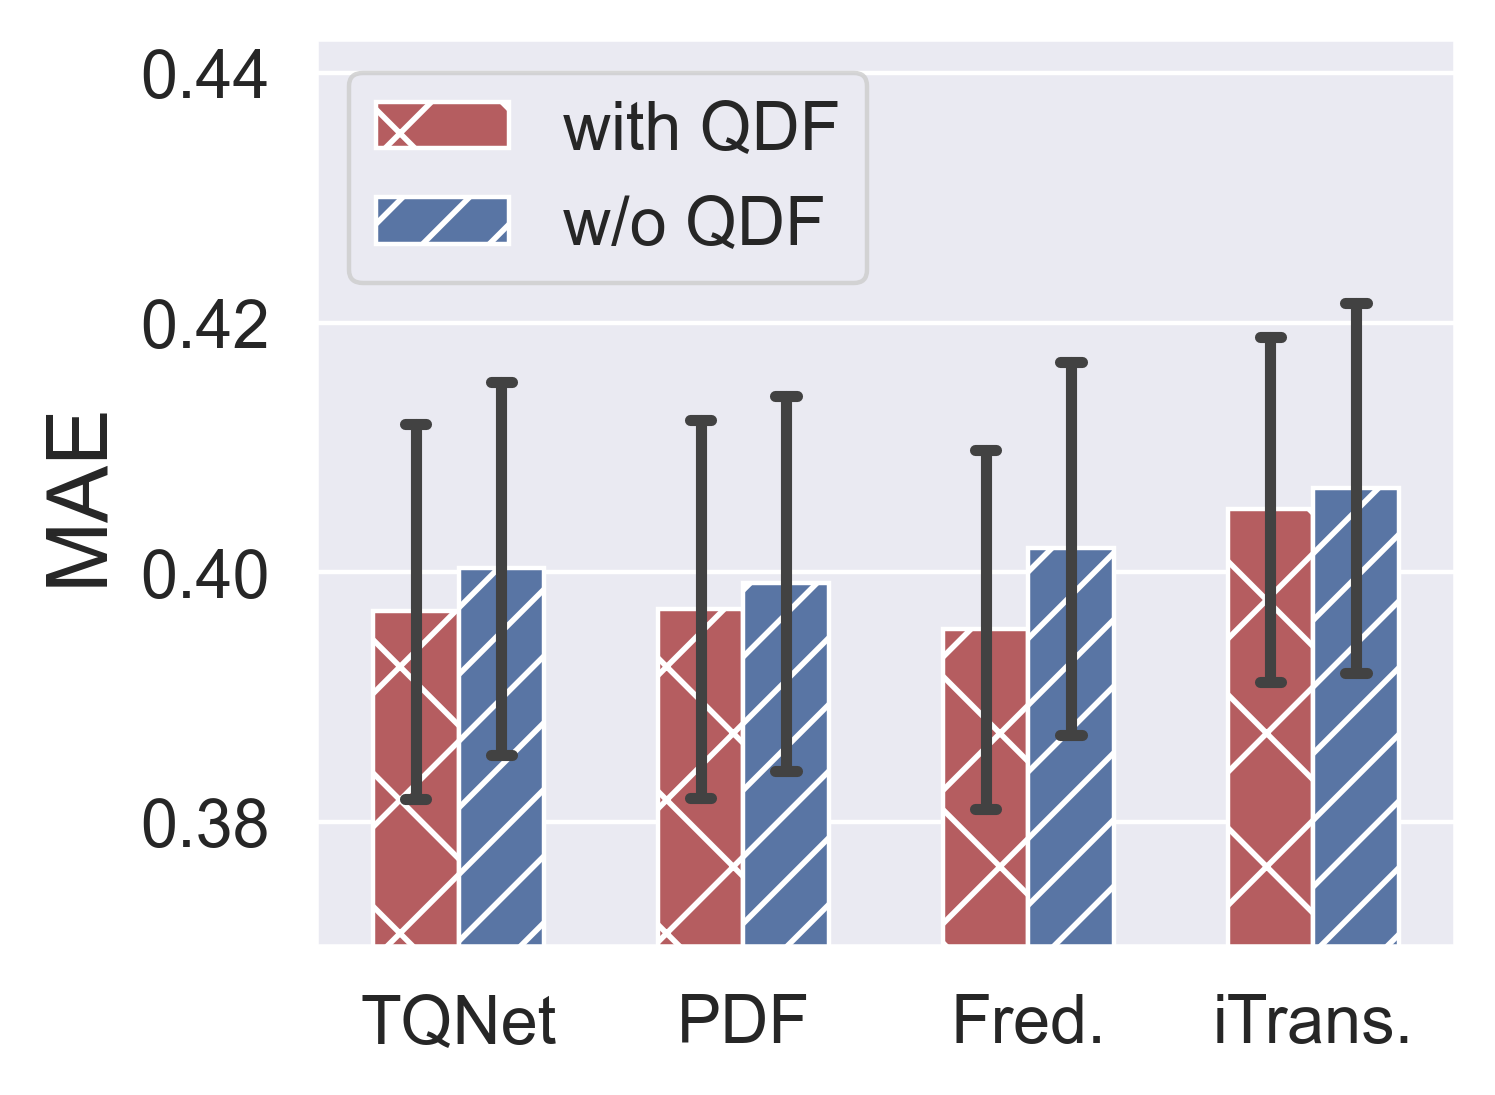

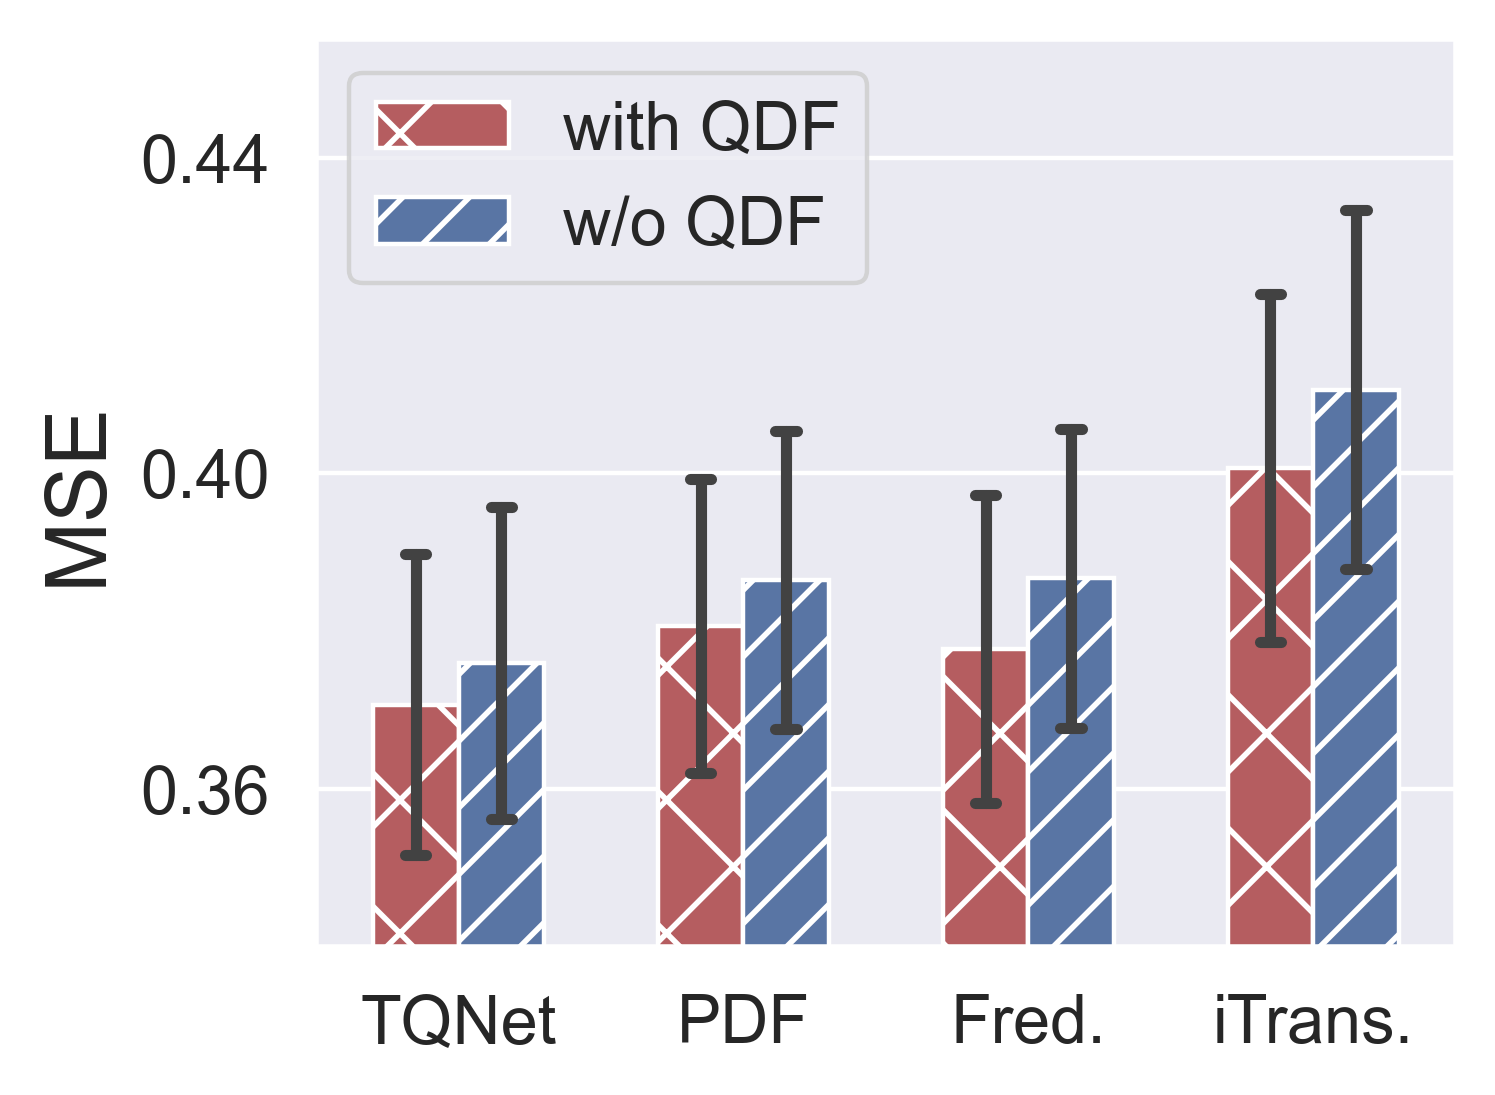

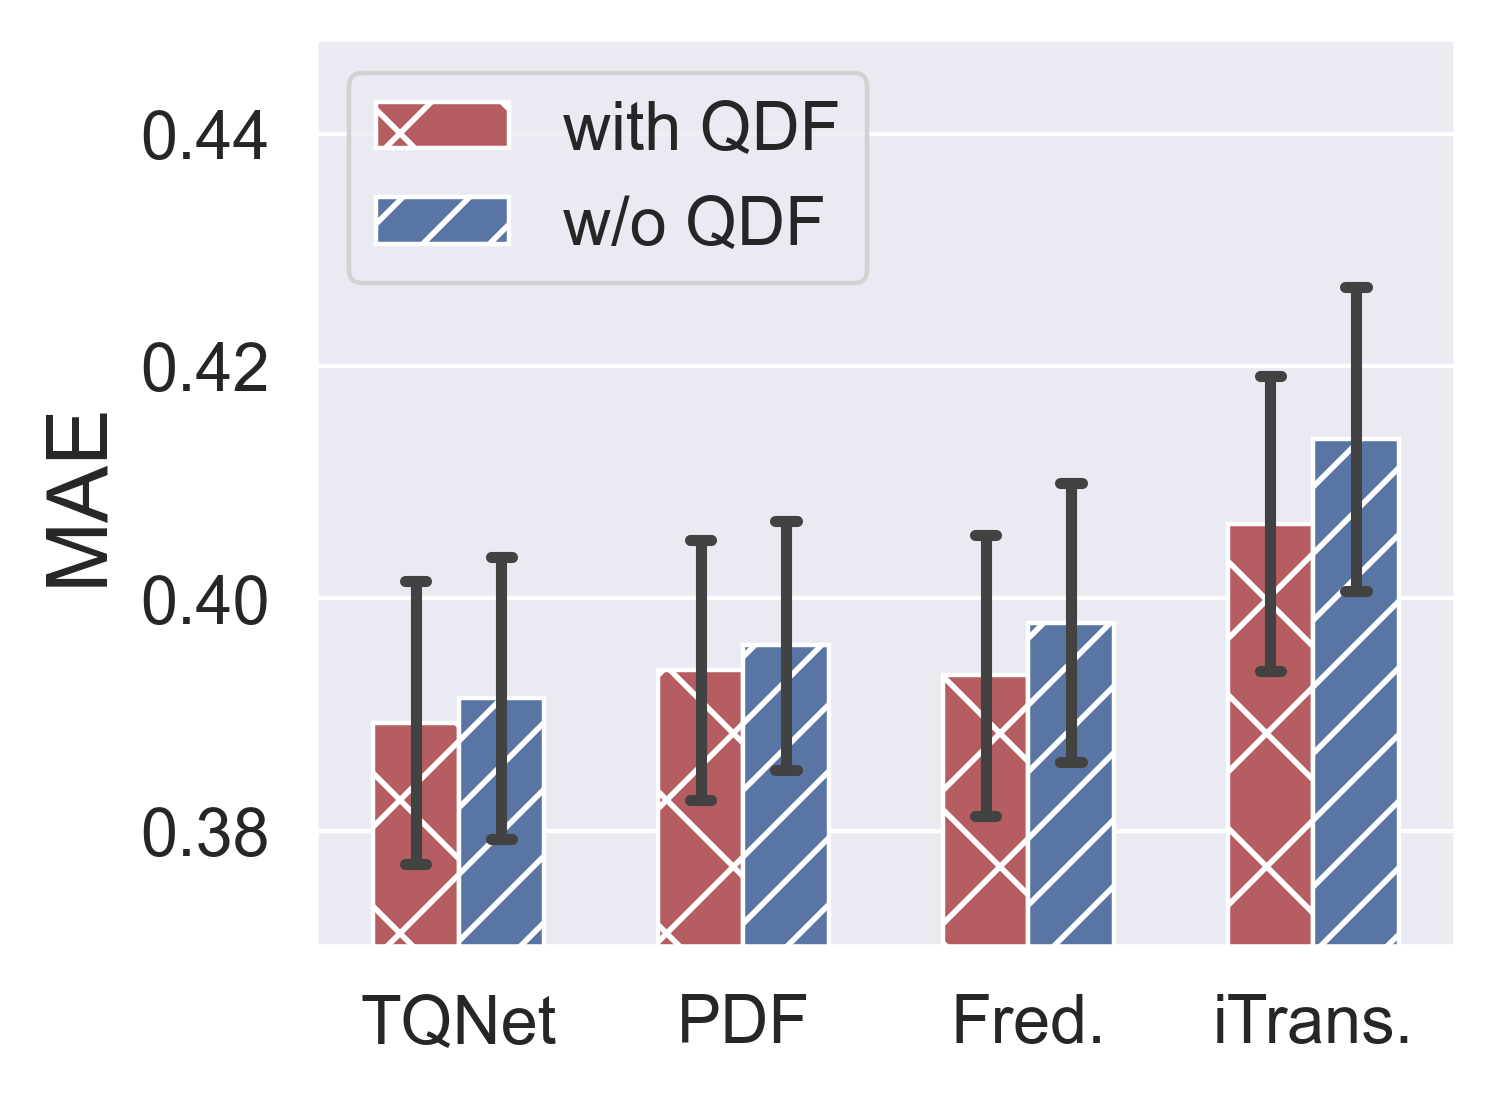

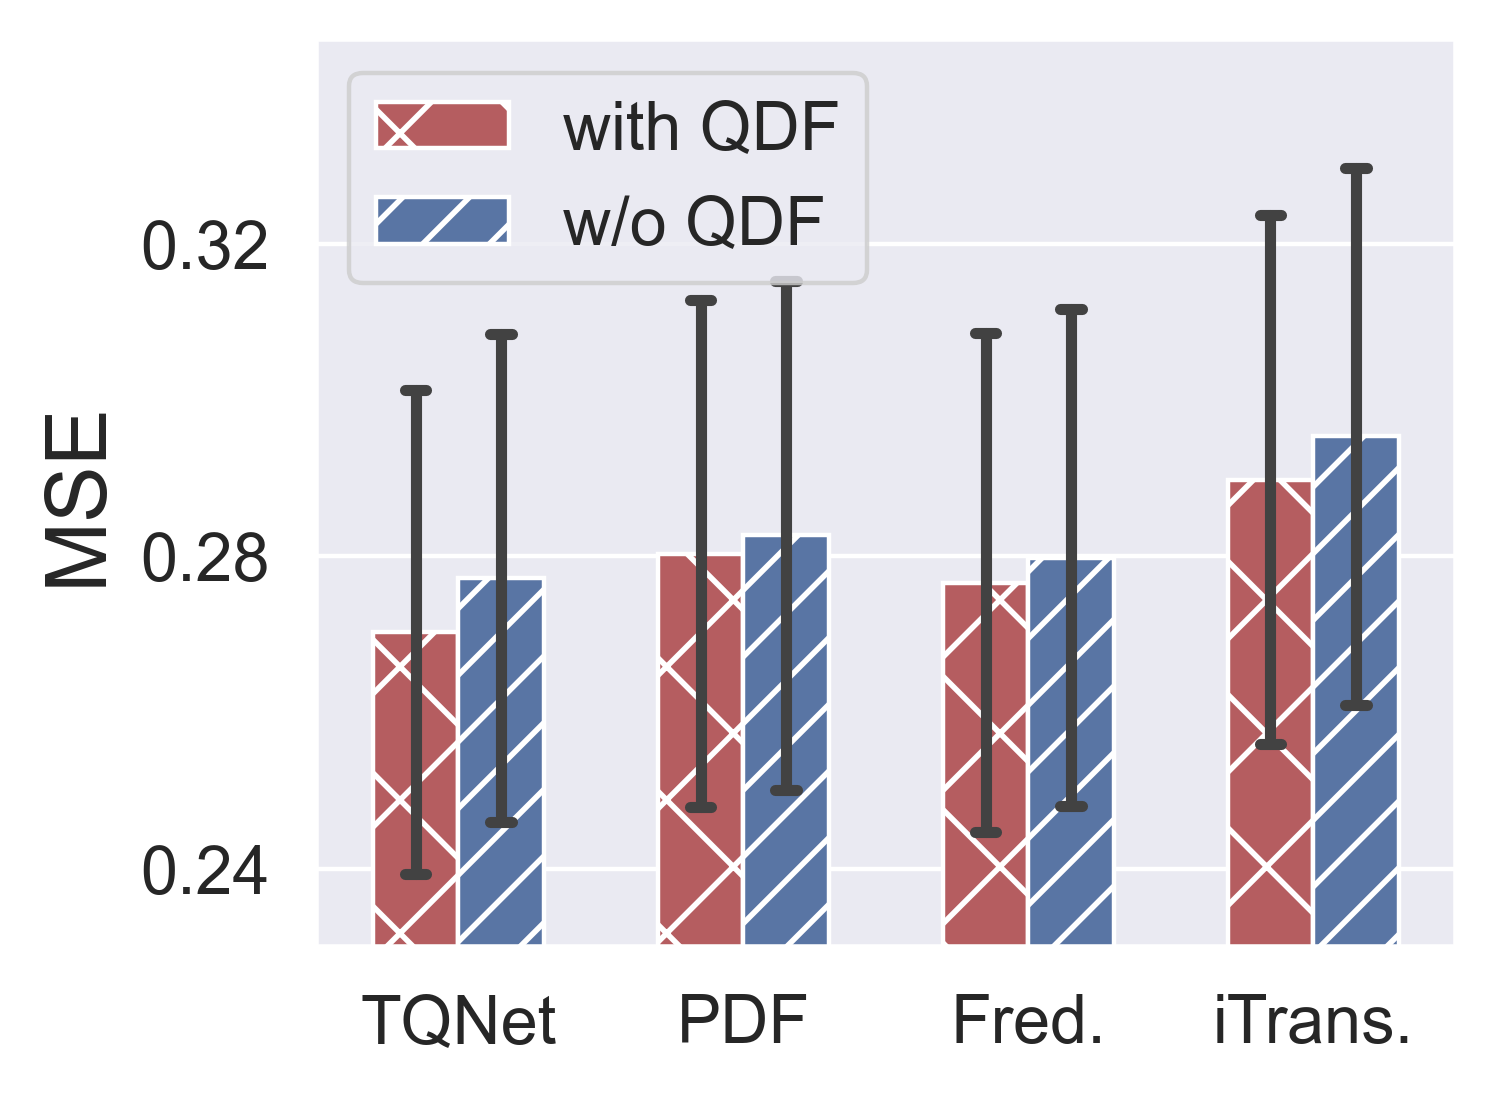

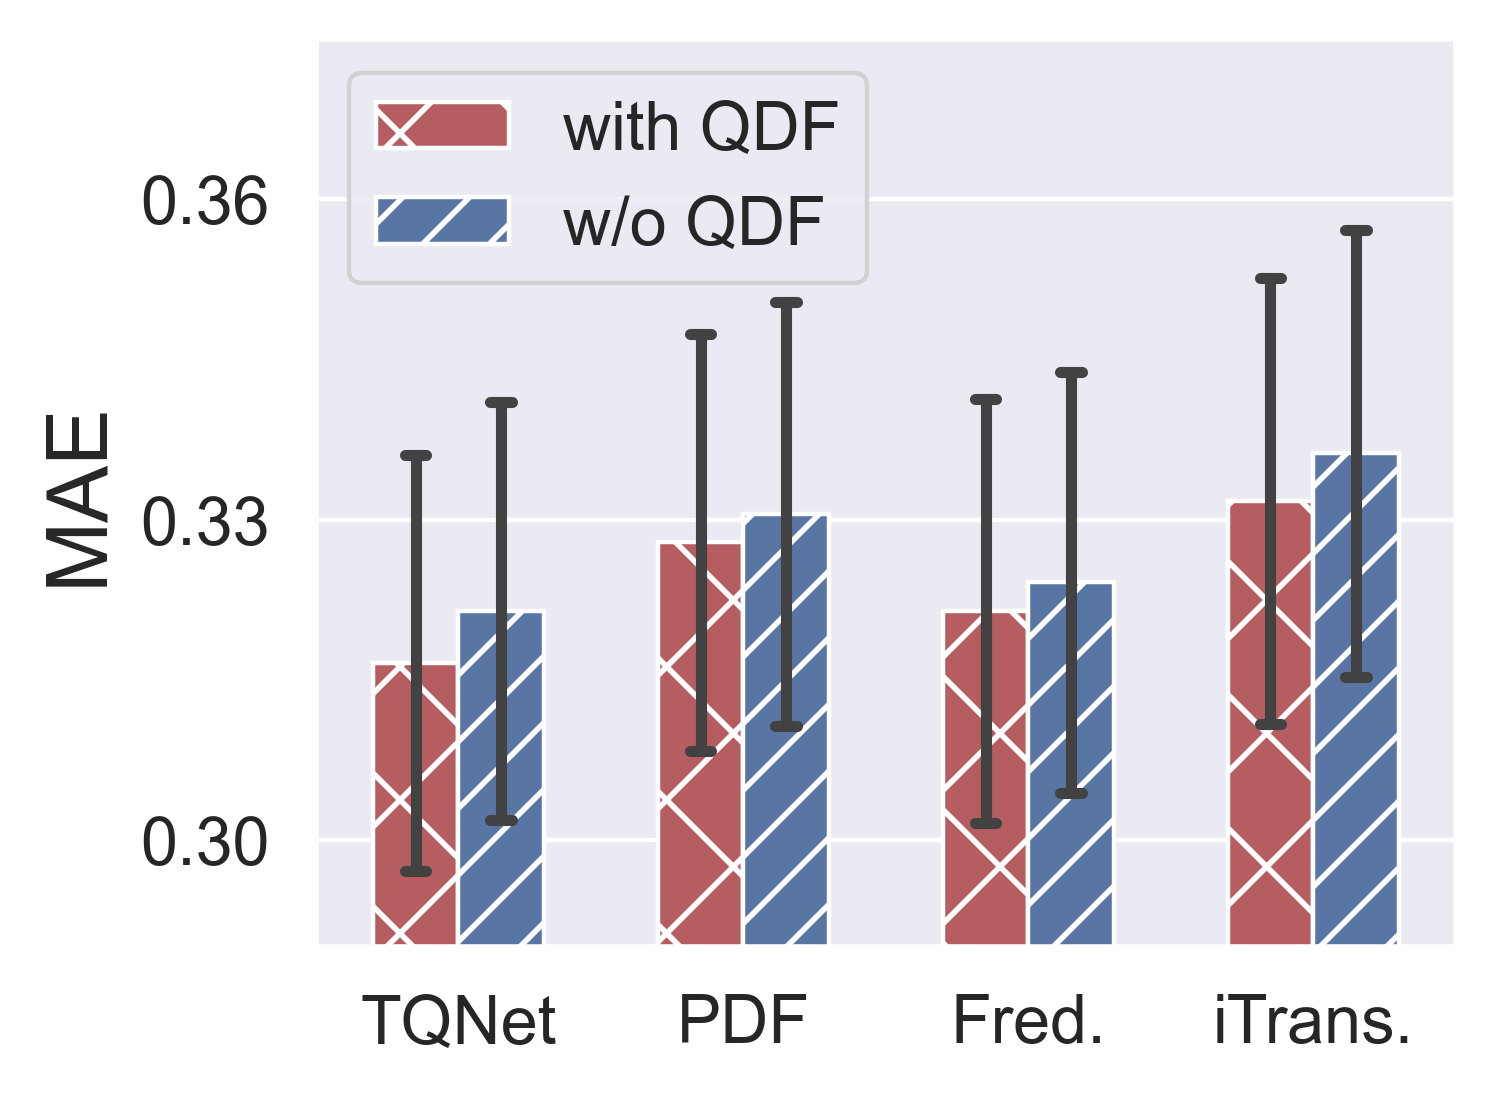

In [28]:
def plot(df, save_dir, dataset, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None, loc1=None, loc2=None):
    labelsize = 12
    width = 0.6
    base = 1
    hatchs = ['x', '//']
    ci = 50
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mse', hue='label', data=df, palette=palette[:2], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*4, (j+1)*4)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,10), hatchs)]

    legend_location = 'lower right' if loc1 is None else loc1
    ax = plt.gca()
    plt.legend(fontsize=labelsize, ncols=1, loc=legend_location)
    plt.xlabel('')
    plt.ylabel('MSE')
    # plt.yscale('log', base=2)
    plt.tick_params(labelsize=labelsize)
    if ylim1:
        plt.ylim(ylim1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MSE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


    f = plt.figure(dpi=400, figsize=(4, 3))
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    bar = sns.barplot(x=x, y='mae', hue='label', data=df, palette=palette[:2], err_kws={'linewidth': 2}, capsize=0.15, errorbar=errorbar, width=width)
    for j, hatch in enumerate(hatchs):
        [bar.patches[i].set_hatch(hatch) for i in range(j*4, (j+1)*4)];
    [bar.patches[i].set_hatch(hatch) for i, hatch in zip(range(8,10), hatchs)]

    legend_location = 'lower right' if loc2 is None else loc2

    ax = plt.gca()
    # ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    plt.legend(fontsize=labelsize, ncols=1, loc=legend_location)
    plt.ylabel('MAE')
    plt.xlabel('')
    plt.tick_params(labelsize=labelsize)
    if ylim2:
        plt.ylim(ylim2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))
    plt.tight_layout()

    with PdfPages(os.path.join(save_dir, f'{figure_name}_MAE.pdf')) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.02)


dfp = df.copy()

figure_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
save_dir = f'{figure_root}/backbones'
os.makedirs(save_dir, exist_ok=True)

data_id = 'ETTh1'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=0.03, ypad2=0.03, ylim1=[0.41, None], ylim2=[0.41, None], loc1='upper left', loc2='upper left')


data_id = 'ETTh2'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=0.02, ypad2=0.02, ylim1=[0.33, None], ylim2=[0.37, None], loc1='upper left', loc2='upper left')


data_id = 'ETTm1'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=0.04, ypad2=0.02, ylim1=[0.34, None], ylim2=[0.37, None], loc1='upper left', loc2='upper left')


data_id = 'ETTm2'
dfp_ = dfp[(dfp.data_id == data_id)]
plot(dfp_, save_dir=save_dir, dataset=data_id, x='model', figure_name=f'{data_id}', ypad1=0.04, ypad2=0.03, ylim1=[0.23, None], ylim2=[0.29, None], loc1='upper left', loc2='upper left')